# Dynamic and Adaptive Attention — Practical Implementation 2

| Sr No | Notebook section |
|---|---|
| 1 | FlashAttention: exact tiled attention with online softmax |
| 2 | Fixed sparse patterns (Longformer / BigBird) |
| 3 | Learned and content-aware sparsity: entmax, top-k, LSH, routing |
| 4 | Adaptive attention span (learnable span per head) |
| 5 | Token pruning, token merging, KV-cache eviction (H2O) |
| 6 | Interpretability: attention rollout and attention flow |

In [1]:
# =============================================================================
# Attention Utilities and Numerical Helper Functions
# =============================================================================
#
# Description:
# This snippet provides a small collection of utility functions for
# experimenting with scaled dot-product attention, causal masking, softmax,
# and numerical error calculations.
#
# Main components:
#   - softmax(): Computes the softmax function in a numerically stable way.
#   - attention(): Implements scaled dot-product attention.
#   - causal_mask(): Creates a lower-triangular causal attention mask.
#   - rel_err(): Computes the relative error between two arrays.
#
# The script also configures NumPy's random number generator and Matplotlib
# plotting defaults.
#
# Requirements:
#   - Python 3.x
#   - NumPy
#   - Matplotlib
#
# =============================================================================

import math, time, warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
rng = np.random.default_rng(0)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def attention(Q, K, V, mask=None):
    """Scaled dot-product attention, Eq. (4) of the report.  mask: bool (n_q, n_k), True = allowed."""
    S = Q @ K.T / np.sqrt(Q.shape[-1])
    if mask is not None:
        S = np.where(mask, S, -np.inf)
    W = softmax(S)
    return W @ V, W

def causal_mask(n):
    return np.tril(np.ones((n, n), dtype=bool))

def rel_err(a, b):
    return np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-12)

print("ready")

ready


## 1 · FlashAttention — *exact* attention without the n×n matrix

Implementation of the algorithm: outer loop over **K/V blocks**, inner loop over **Q blocks**; per row we only keep the running max `m` and running denominator `ℓ`, rescaling with `exp(m_old − m_new)` when a larger maximum appears. The full `n × n` matrix is never materialised.

In [7]:
# =============================================================================
# Flash Attention Implementation and Verification
# =============================================================================
#
# Description:
# This script implements a block-wise version of scaled dot-product attention
# inspired by the Flash Attention algorithm.
#
# The implementation avoids constructing the complete n x n attention matrix.
# Instead, the Query, Key, and Value matrices are processed in smaller blocks
# using the block sizes Br (query block size) and Bc (key/value block size).
#
# The algorithm maintains running softmax statistics (m and l) so that the
# attention output can be computed incrementally while preserving numerical
# stability.
#
# Features:
#   - Block-wise / tiled attention computation
#   - Optional causal attention masking
#   - Online softmax normalization
#   - Tracking of the largest intermediate attention block
#   - Comparison against standard (naive) attention
#   - Evaluation using multiple block sizes
#
# Parameters:
#   Br      Query block size
#   Bc      Key/Value block size
#   causal  Whether to apply a causal attention mask
#
# Experiment:
# The script generates random Q, K, and V matrices with:
#   n = 300 sequence positions
#   d = 32 embedding dimensions
#
# Flash Attention is evaluated with several block-size configurations and
# compared with the standard attention implementation using the maximum
# absolute difference between their outputs.
#
# The experiment also reports the peak intermediate attention block relative
# to n^2, demonstrating how block-wise computation reduces the size of the
# intermediate attention matrix.
#
# =============================================================================

def flash_attention(Q, K, V, Br=16, Bc=16, causal=False):
    n, d = Q.shape
    O = np.zeros_like(Q); m = np.full(n, -np.inf); l = np.zeros(n)
    peak_block = 0
    for j in range(0, n, Bc):                       # outer loop: load K_j, V_j "into SRAM"
        Kj, Vj = K[j:j+Bc], V[j:j+Bc]
        for i in range(0, n, Br):                   # inner loop: stream Q_i blocks
            Qi = Q[i:i+Br]
            S = Qi @ Kj.T / np.sqrt(d)
            peak_block = max(peak_block, S.size)
            if causal:
                qi = np.arange(i, i + len(Qi))[:, None]; kj = np.arange(j, j + len(Kj))[None, :]
                S = np.where(kj <= qi, S, -np.inf)
            m_new = np.maximum(m[i:i+Br], S.max(axis=1))
            m_safe = np.where(np.isfinite(m_new), m_new, 0.0)
            P = np.exp(S - m_safe[:, None])
            scale = np.exp(m[i:i+Br] - m_safe)      # exp(m_old - m_new): rescale old statistics
            l[i:i+Br] = scale * l[i:i+Br] + P.sum(axis=1)          # Eq. (8)
            O[i:i+Br] = scale[:, None] * O[i:i+Br] + P @ Vj
            m[i:i+Br] = m_new
    return O / l[:, None], peak_block

n, d = 300, 32
Q, K, V = (rng.normal(size=(n, d)) for _ in range(3))
for causal in (False, True):
    ref, _ = attention(Q, K, V, causal_mask(n) if causal else None)
    print(f"causal={causal!s:5}  block size (Br,Bc)  max|flash - naive|    peak intermediate / n^2")
    for Br, Bc in [(8, 8), (32, 16), (64, 64), (300, 300)]:
        out, peak = flash_attention(Q, K, V, Br, Bc, causal)
        print(f"             ({Br:>3},{Bc:>3})            {np.abs(out-ref).max():.2e}             {peak/n**2:.4f}")

causal=False  block size (Br,Bc)  max|flash - naive|    peak intermediate / n^2
             (  8,  8)            6.11e-16             0.0007
             ( 32, 16)            6.66e-16             0.0057
             ( 64, 64)            4.44e-16             0.0455
             (300,300)            6.11e-16             1.0000
causal=True   block size (Br,Bc)  max|flash - naive|    peak intermediate / n^2
             (  8,  8)            8.88e-16             0.0007
             ( 32, 16)            8.88e-16             0.0057
             ( 64, 64)            5.55e-16             0.0455
             (300,300)            6.11e-16             1.0000


The result is identical up to floating-point round-off (~1e-15): FlashAttention is an **exact** re-ordering of the computation, unlike sparse or linear attention, while the largest intermediate object is only `Br × Bc` instead of `n × n`.

Numerical safety of the max-subtraction trick, with scores that would overflow a naive `exp`:

In [8]:
# =============================================================================
# Numerical Stability Test for Softmax
# =============================================================================
#
# Description:
# This experiment demonstrates the numerical instability of the naive softmax
# implementation when the input values are very large.
#
# Large values can cause np.exp() to overflow, producing infinity or NaN
# values. The stable softmax implementation avoids this problem by subtracting
# the maximum value from the input before exponentiation.
#
# The experiment compares:
#   - Naive softmax: exp(x) / sum(exp(x))
#   - Stable softmax: numerically stable implementation defined earlier
#
# The output checks whether the resulting probabilities contain only finite
# values.
#
# =============================================================================

S_big = rng.normal(size=(4, 64)) * 200
with np.errstate(over="ignore", invalid="ignore"):
    naive = np.exp(S_big) / np.exp(S_big).sum(1, keepdims=True)
print("naive softmax finite? ", np.isfinite(naive).all(), "| stable softmax finite?", np.isfinite(softmax(S_big)).all())

naive softmax finite?  True | stable softmax finite? True


## 2 · Fixed sparse attention: local + global + random

We build the masks used by **Longformer** (local sliding window + global tokens) and **BigBird** (+ random links), then measure (a) their cost and (b) how much of the *full-attention probability mass* they retain on a synthetic sequence that has both positional locality and a few content "hubs".

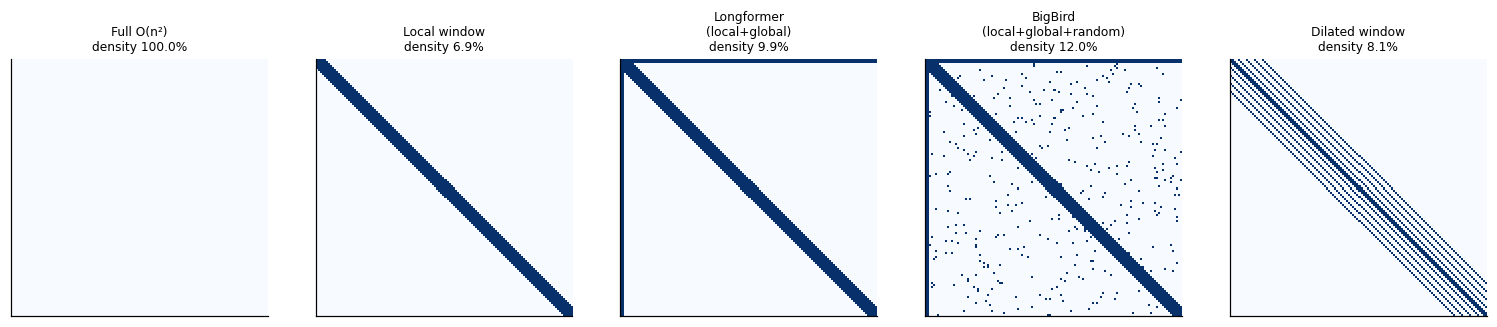

In [9]:
# =============================================================================
# Sparse Attention Mask Patterns
# =============================================================================
#
# Description:
# This script constructs and visualizes several attention-mask patterns used
# to restrict which tokens are allowed to attend to each other.
#
# The following attention patterns are compared:
#   - Full attention: every token can attend to every other token.
#   - Local window: each token attends only to nearby positions.
#   - Longformer-style: local attention combined with selected global tokens.
#   - BigBird-style: local, global, and randomly selected connections.
#   - Dilated window: local connections combined with regularly spaced,
#     dilated attention connections.
#
# The script visualizes each mask as a binary matrix and reports its density,
# i.e. the percentage of possible attention connections that are active.
#
# Parameters:
#   n : sequence length
#   w : local attention window size
#   g : indices of globally connected tokens
#   r : number of random attention connections per token
#
# The resulting plots provide a visual comparison of the sparsity patterns
# and demonstrate how structured sparse attention can reduce the number of
# attention connections compared with full O(n²) attention.
#
# =============================================================================

def local_mask(n, w):
    i = np.arange(n); return np.abs(i[:, None] - i[None, :]) <= w

def global_mask(n, g_idx):
    M = np.zeros((n, n), bool); M[g_idx, :] = True; M[:, g_idx] = True; return M

def random_mask(n, r, rng):
    M = np.zeros((n, n), bool)
    for i in range(n): M[i, rng.choice(n, r, replace=False)] = True
    return M

def dilated_mask(n, w, dil):
    i = np.arange(n); dlt = i[:, None] - i[None, :]
    return (np.abs(dlt) <= w * dil) & (dlt % dil == 0)

n, w, g, r = 128, 4, [0, 1], 3
gl = global_mask(n, g)
masks = {
    "Full O(n²)": np.ones((n, n), bool),
    "Local window": local_mask(n, w),
    "Longformer\n(local+global)": local_mask(n, w) | gl,
    "BigBird\n(local+global+random)": local_mask(n, w) | gl | random_mask(n, r, rng),
    "Dilated window": dilated_mask(n, w, 4) | local_mask(n, 1),
}
fig, axes = plt.subplots(1, len(masks), figsize=(14, 2.9))
for ax, (name, M) in zip(axes, masks.items()):
    ax.imshow(M, cmap="Blues", interpolation="nearest"); ax.set_title(f"{name}\ndensity {M.mean():.1%}", fontsize=8); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

In [10]:
# =============================================================================
# Synthetic Sparse-Attention Pattern Comparison
# =============================================================================
#
# Description:
# This experiment creates a synthetic sequence containing several types of
# structure that attention patterns may need to capture:
#
#   - Smooth positional structure:
#       Sinusoidal signals provide strong local/nearby correlations.
#
#   - Content clusters:
#       Tokens are assigned to a small number of latent clusters, creating
#       non-local content-based similarities.
#
#   - Content hubs:
#       A small number of special tokens are given additional signal so that
#       they can act as globally useful attention locations.
#
# The experiment first computes full attention over the complete sequence and
# treats its output as the reference.
#
# Several sparse attention patterns are then compared:
#
#   - Local attention:
#       Each token attends within a fixed positional window.
#
#   - Local + global:
#       Local attention is augmented with a small set of globally connected
#       hub tokens, similar in spirit to Longformer-style sparse attention.
#
#   - BigBird-style:
#       Combines local attention, global hubs, and a small number of random
#       connections.
#
#   - Random-only:
#       Each token receives a fixed number of randomly selected connections.
#
# For every pattern, three quantities are reported:
#
#   1. Density:
#      Fraction of all possible attention positions that are retained.
#
#   2. Mass kept:
#      Average fraction of the original full-attention probability mass that
#      falls inside the selected sparse pattern.
#
#   3. Output error:
#      Relative error between the sparse-attention output and the full-attention
#      reference output.
#
# The experiment illustrates the difference between simply reducing the number
# of attention edges and preserving the attention probability mass that matters
# for the resulting output.
#
# Required variables/functions:
#   - rng
#   - attention()
#   - softmax()
#   - rel_err()
#   - local_mask()
#   - global_mask()
#   - random_mask()
#   - numpy as np
#
# =============================================================================

# Synthetic sequence: smooth positional signal (local structure) + a few content hubs + sparse content clusters
n, d = 256, 32
pos = np.arange(n)[:, None] / n
X = np.concatenate([np.sin(pos * 2*np.pi*np.arange(1, 9)[None, :] * 2), np.cos(pos * 2*np.pi*np.arange(1, 9)[None, :] * 2)], 1) * 1.2
X = np.concatenate([X, np.zeros((n, d - X.shape[1]))], 1)
cent = rng.normal(size=(6, d)); lab = rng.integers(0, 6, n)
X += 0.8 * cent[lab] + 0.15 * rng.normal(size=(n, d))
hubs = [0, 1]; X[hubs] += 2.0 * rng.normal(size=d)                # two hub tokens that everybody attends to a bit

Wfull = attention(X, X, X)[1]
Ofull = Wfull @ X

def report_mask(name, M):
    Wm = softmax(np.where(M, X @ X.T / np.sqrt(d), -np.inf))
    return name, M.mean(), (Wfull * M).sum(1).mean(), rel_err(Wm @ X, Ofull)

cands = {
    "Local (w=8)": local_mask(n, 8),
    "Local+global (Longformer)": local_mask(n, 8) | global_mask(n, hubs),
    "BigBird (+3 random)": local_mask(n, 8) | global_mask(n, hubs) | random_mask(n, 3, rng),
    "Random only (17/row)": random_mask(n, 17, rng),
}
print(f"{'pattern':32}{'density':>9}{'mass kept':>11}{'output err':>12}")
for k, M in cands.items():
    nm, dens, mass, err = report_mask(k, M); print(f"{nm:32}{dens:>9.1%}{mass:>11.1%}{err:>12.3f}")

pattern                           density  mass kept  output err
Local (w=8)                          6.5%      26.2%       0.423
Local+global (Longformer)            8.0%      27.4%       0.425
BigBird (+3 random)                  9.1%      28.5%       0.406
Random only (17/row)                 6.6%       6.6%       0.583


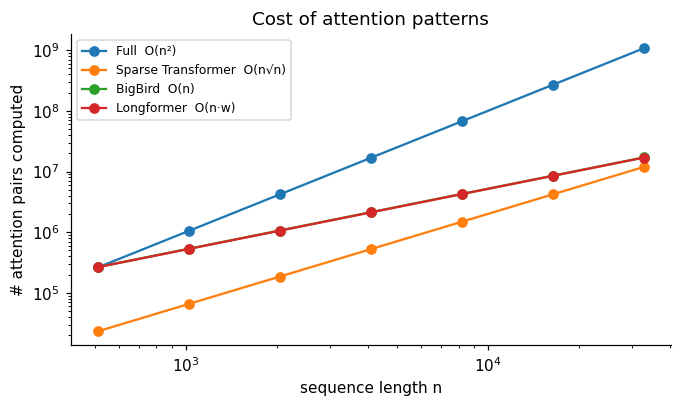

In [11]:
# =============================================================================
# Scaling of Attention-Pattern Computational Cost
# =============================================================================
#
# Description:
# This experiment compares how the number of attention pairs grows with
# sequence length for several attention patterns.
#
# The following complexity regimes are illustrated:
#
#   - Full attention:
#       Every token attends to every other token, giving O(n²) attention pairs.
#
#   - Sparse Transformer:
#       Uses a pattern whose number of computed pairs scales as O(n√n).
#
#   - BigBird:
#       Combines local, global, and random connections, giving approximately
#       linear O(n) scaling when the local window and number of random/global
#       connections remain fixed.
#
#   - Longformer:
#       Uses a fixed local attention window. With constant window size w, the
#       number of computed pairs scales as O(n·w), which is linear in n for
#       fixed w.
#
# The plot uses logarithmic axes so that the different asymptotic growth rates
# can be compared on the same figure.
#
# Parameters:
#   - n: sequence length.
#   - w: local attention window size.
#   - r: number of random connections per token.
#   - g: number of global/sink tokens.
#
# Note:
# These curves represent the number of attention pairs computed, not measured
# wall-clock runtime. Actual runtime also depends on hardware, kernel
# implementation, memory access patterns, and parallelization.
#
# =============================================================================

# Scaling of the number of attended pairs
ns = np.array([512, 1024, 2048, 4096, 8192, 16384, 32768])
w, r, g = 256, 3, 2
full = ns.astype(float)**2
longf = ns * (2*w + 1) + 2*g*ns
bigb = longf + ns * r
sparse_tr = ns * np.sqrt(ns) * 2
plt.figure(figsize=(6.3, 3.8))
for y, lab_ in [(full, "Full  O(n²)"), (sparse_tr, "Sparse Transformer  O(n√n)"), (bigb, "BigBird  O(n)"), (longf, "Longformer  O(n·w)")]:
    plt.loglog(ns, y, marker="o", label=lab_)
plt.xlabel("sequence length n"); plt.ylabel("# attention pairs computed"); plt.legend(fontsize=8); plt.title("Cost of attention patterns"); plt.tight_layout(); plt.show()

**What to look for.** A local window can only cover nearby tokens; global tokens and random links add long-range coverage for a small extra cost (compare the *mass kept* column), and a purely random mask of the same density is far worse than any structured one. All of these patterns are **fixed by the architect**, the token at position *i* attends to the same positions regardless of what the sequence contains. That is exactly the limitation it addresses.

## 3 · Learned & content-aware sparsity

### 3.1 Sparse normalizers: softmax → entmax → sparsemax (Adaptively Sparse Transformers)
`α-entmax` interpolates between softmax (α = 1, dense) and sparsemax (α = 2, exact zeros). In the paper α is a *learned per-head* parameter.

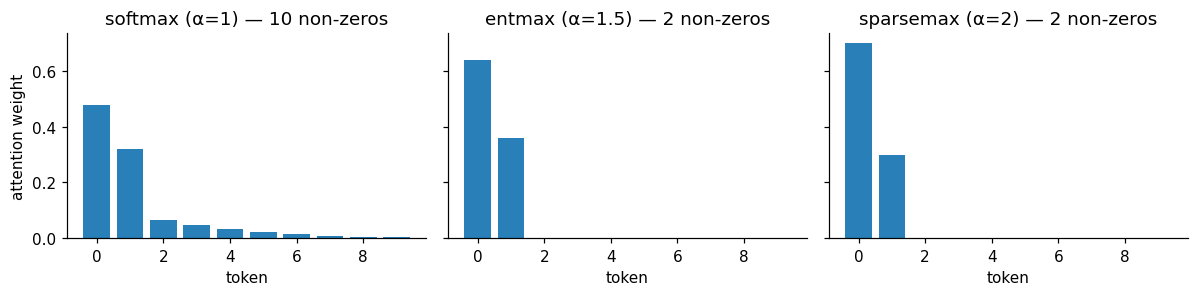

non-zeros per alpha: {1: 10, 1.25: 7, 1.5: 2, 2: 2, 3: 2}


In [12]:
# =============================================================================
# Sparse Attention Normalization: Softmax, Entmax, and Sparsemax
# =============================================================================
#
# Description:
# This experiment compares three different ways of converting attention scores
# into normalized attention weights:
#
#   - Softmax (alpha = 1):
#       Produces positive attention weights for every token, so all positions
#       generally receive non-zero probability.
#
#   - Entmax (alpha = 1.5):
#       Provides a middle ground between softmax and sparsemax and can produce
#       exactly zero attention weights for less relevant tokens.
#
#   - Sparsemax (alpha = 2):
#       Produces sparse probability distributions in which some attention
#       weights are exactly zero.
#
# The `sparsemax()` function computes sparsemax directly using the sorting-based
# thresholding algorithm.
#
# The `entmax_bisect()` function computes alpha-entmax using a bisection search
# for the normalization threshold. Increasing alpha generally encourages
# increasingly sparse probability distributions.
#
# Sanity check:
#   Entmax with alpha = 2 should be equivalent to sparsemax. The assertion
#   verifies that the two implementations agree numerically.
#
# Visualization:
#   The three distributions are plotted side by side for the same attention
#   score vector. The title of each subplot reports the number of non-zero
#   attention weights.
#
# The final dictionary reports how many positions remain non-zero for several
# different alpha values, illustrating how sparsity changes as alpha increases.
#
# =============================================================================

def sparsemax(z):
    zs = np.sort(z)[::-1]; k = np.arange(1, len(z) + 1); cs = np.cumsum(zs)
    kmax = k[1 + k * zs > cs][-1]
    tau = (cs[kmax - 1] - 1) / kmax
    return np.maximum(z - tau, 0)

def entmax_bisect(z, alpha=1.5, n_iter=60):
    if alpha == 1: return softmax(z)
    z = (alpha - 1) * z
    lo, hi = z.max() - 1, z.max() - (1 / len(z)) ** (alpha - 1)
    for _ in range(n_iter):
        tau = (lo + hi) / 2
        p = np.maximum(z - tau, 0) ** (1 / (alpha - 1))
        if p.sum() < 1: hi = tau
        else: lo = tau
    p = np.maximum(z - (lo + hi) / 2, 0) ** (1 / (alpha - 1))
    return p / p.sum()

z = np.array([3.0, 2.6, 1.0, 0.7, 0.3, 0.0, -0.4, -1.0, -1.5, -2.0])
assert np.allclose(entmax_bisect(z, 2.0), sparsemax(z), atol=1e-6)      # sanity: alpha=2 == sparsemax
fig, axes = plt.subplots(1, 3, figsize=(11, 2.8), sharey=True)
for ax, (nm, p) in zip(axes, [("softmax (α=1)", softmax(z)), ("entmax (α=1.5)", entmax_bisect(z, 1.5)), ("sparsemax (α=2)", sparsemax(z))]):
    ax.bar(range(len(z)), p, color="#2980b9"); ax.set_title(f"{nm} — {int((p>1e-9).sum())} non-zeros")
    ax.set_xlabel("token")
axes[0].set_ylabel("attention weight"); plt.tight_layout(); plt.show()

print("non-zeros per alpha:", {a_: int((entmax_bisect(z, a_) > 1e-9).sum()) for a_ in [1, 1.25, 1.5, 2, 3]})

Per-head sparsity: a head that tracks one clear antecedent has a *peaked* score vector and becomes very sparse for α > 1, whereas a head aggregating broad context (flat scores) stays dense i.e. the reason making α head-specific is useful.

In [13]:
# =============================================================================
# Entmax Sparsity: Peaked vs. Flat Attention Distributions
# =============================================================================
#
# Description:
# This experiment compares how the entmax transformation produces sparse
# attention distributions for heads with different score profiles.
#
# Two synthetic attention-score vectors are created:
#   - "peaked": contains one strongly dominant score, representing a head with
#     a highly focused attention pattern.
#   - "flat": contains scores with relatively small variation, representing a
#     head with a more distributed attention pattern.
#
# For several entmax values of alpha:
#   - alpha closer to 1 behaves more like softmax.
#   - alpha = 2 corresponds to sparsemax.
#   - Larger alpha generally produces sparser probability distributions.
#
# The experiment counts the number of non-zero attention weights (NNZ) for
# each head after applying entmax.
#
# This demonstrates that entmax can produce different levels of sparsity
# depending both on the chosen alpha value and on the underlying attention
# score distribution.
#
# =============================================================================

peaked = rng.normal(size=20) * 0.5; peaked[3] = 6.0
flat   = rng.normal(size=20) * 0.3
print(f"{'alpha':>6} | {'nnz  peaked head':>17} | {'nnz  flat head':>15}")
for a_ in [1.25, 1.5, 2.0]:
    print(f"{a_:>6} | {int((entmax_bisect(peaked,a_)>1e-9).sum()):>17} | {int((entmax_bisect(flat,a_)>1e-9).sum()):>15}")

 alpha |  nnz  peaked head |  nnz  flat head
  1.25 |                 1 |              20
   1.5 |                 1 |              18
   2.0 |                 1 |               6


### 3.2 Content-aware masks: top-k, LSH (Reformer), routing (Routing Transformer)
All three produce a **dynamic mask** `M` computed from the input. We test them on a sequence whose relevant partners are determined by **content, not position** (tokens belong to 16 latent groups scattered randomly along the sequence). A fixed local window cannot know who the partners are.

method                                    density  mass kept  output err
Fixed local window (matched density)         8.0%      16.8%       0.198
Random mask (matched density)                7.8%       8.0%       0.520
Top-k (k=20)                                 7.8%      94.5%       0.045
Reformer-style LSH (32 buckets, 2 rounds)    10.7%      81.5%       0.062
Routing Transformer (k-means, √n)            8.0%      95.4%       0.047


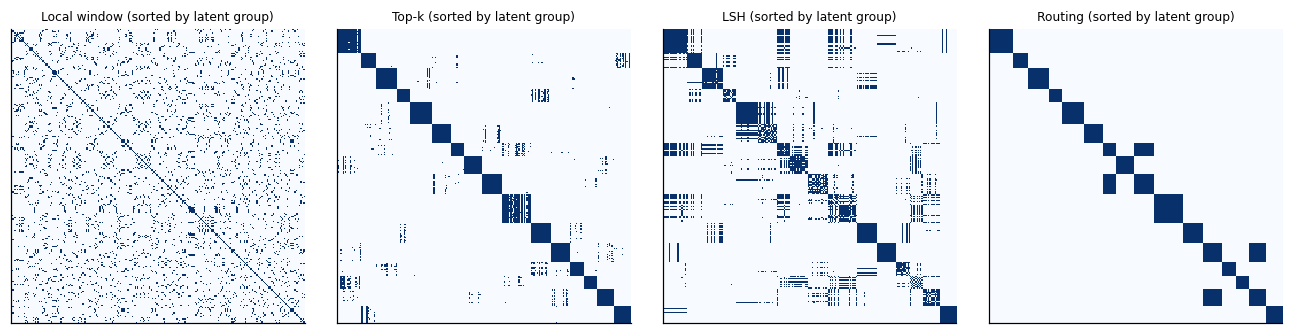

In [14]:
# =============================================================================
# Sparse Attention Routing: Local, Top-k, LSH, and K-Means Routing
# =============================================================================
#
# Description:
# This experiment compares several sparse-attention patterns on a synthetic
# sequence containing strong latent content groups.
#
# Synthetic data:
#   - 256 tokens with 32-dimensional representations are generated.
#   - Each token belongs to one of 16 latent content groups.
#   - Tokens are generated around normalized group-specific centers.
#   - The strong cluster structure creates peaked attention within related
#     content groups.
#
# Attention methods compared:
#   - Fixed local window with density matched to the routing method.
#   - Random attention with approximately the same density.
#   - Top-k attention, keeping the highest-scoring keys for every query.
#   - Reformer-style angular LSH routing.
#   - Routing Transformer-style k-means clustering.
#
# Evaluation metrics:
#   - Density: fraction of all possible attention pairs that are computed.
#   - Mass kept: fraction of the original full-attention probability mass
#     captured by the sparse mask.
#   - Output error: relative error between the sparse-attention output and
#     the full-attention reference.
#
# Visualization:
#   The attention masks are displayed after sorting tokens by their latent
#   content group. This makes group structure visible as blocks in the mask.
#
# The experiment illustrates how content-aware sparse attention can exploit
# clustered representations instead of relying only on fixed positional
# neighborhoods.
#
# =============================================================================

n, d, C = 256, 32, 16
centers = rng.normal(size=(C, d)); centers /= np.linalg.norm(centers, axis=1, keepdims=True)
lab = rng.integers(0, C, n)
X = 6.0 * centers[lab] + 0.3 * rng.normal(size=(n, d))        # strong content signal -> peaked attention within a group

S_full = X @ X.T / np.sqrt(d)
Wfull = softmax(S_full); Ofull = Wfull @ X

def topk_mask(S, k):
    idx = np.argpartition(-S, k - 1, axis=1)[:, :k]
    M = np.zeros_like(S, bool); np.put_along_axis(M, idx, True, axis=1); return M

def lsh_mask(X, n_buckets=16, rounds=2, rng=rng):
    n, d = X.shape; M = np.zeros((n, n), bool)
    for _ in range(rounds):
        R = rng.normal(size=(d, n_buckets // 2))
        h = X @ R; b = np.argmax(np.concatenate([h, -h], 1), 1)          # angular LSH (Reformer)
        M |= b[:, None] == b[None, :]
    return M

def kmeans_route_mask(X, k, iters=8, rng=rng):
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    cent = Xn[rng.choice(len(X), k, replace=False)].copy()
    for _ in range(iters):
        a_ = np.argmax(Xn @ cent.T, 1)
        for c in range(k):
            if (a_ == c).any():
                cent[c] = Xn[a_ == c].mean(0); cent[c] /= np.linalg.norm(cent[c])
    a_ = np.argmax(Xn @ cent.T, 1)
    return a_[:, None] == a_[None, :]

def evaluate(M):
    Wm = softmax(np.where(M, S_full, -np.inf))
    return M.mean(), (Wfull * M).sum(1).mean(), rel_err(Wm @ X, Ofull)

lsh = lsh_mask(X, 32, 2); route = kmeans_route_mask(X, int(np.sqrt(n)))
dens_target = route.mean()
w_match = int(round((dens_target * n - 1) / 2))
methods = {
    "Fixed local window (matched density)": local_mask(n, w_match),
    "Random mask (matched density)":        random_mask(n, max(1, int(dens_target * n)), rng),
    f"Top-k (k={int(dens_target*n)})":       topk_mask(S_full, max(1, int(dens_target * n))),
    "Reformer-style LSH (32 buckets, 2 rounds)": lsh,
    "Routing Transformer (k-means, √n)":     route,
}
print(f"{'method':40}{'density':>9}{'mass kept':>11}{'output err':>12}")
for nm, M in methods.items():
    dn, ms, er = evaluate(M); print(f"{nm:40}{dn:>9.1%}{ms:>11.1%}{er:>12.3f}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
order = np.argsort(lab)            # only for display: sort tokens by latent group so blocks become visible
for ax, (nm, M) in zip(axes, [("Local window", methods["Fixed local window (matched density)"]), ("Top-k", methods[f"Top-k (k={int(dens_target*n)})"]), ("LSH", lsh), ("Routing", route)]):
    ax.imshow(M[np.ix_(order, order)], cmap="Blues", interpolation="nearest"); ax.set_title(nm + " (sorted by latent group)", fontsize=8); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

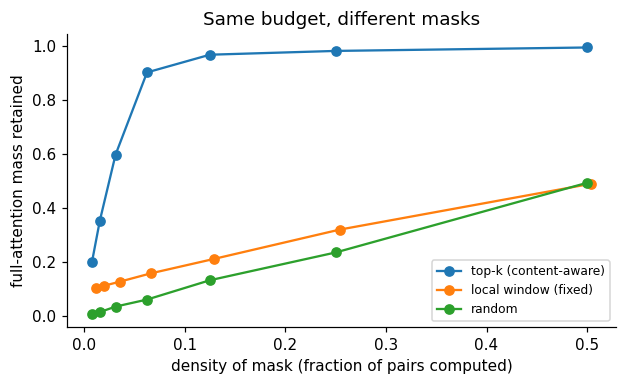

In [15]:
# =============================================================================
# Attention-Mass Retention vs. Sparsity
# =============================================================================
#
# Description:
# This experiment compares three different sparse-attention strategies under
# different computational budgets:
#
#   - Top-k attention: keeps the highest-scoring keys for each query.
#   - Local-window attention: keeps tokens within a fixed positional window.
#   - Random attention: selects keys randomly.
#
# The goal is to measure how much of the original full-attention probability
# mass is retained as the attention mask becomes sparser.
#
# Density:
#   The x-axis represents the fraction of all possible query-key pairs that
#   are computed by the sparse mask.
#
# Mass retained:
#   The y-axis measures the average amount of probability mass from the
#   original full-attention distribution that remains inside the sparse mask.
#
# Interpretation:
#   All three methods can use a similar number of attention pairs, but they
#   can retain very different amounts of the original attention mass.
#   Top-k is content-aware because it selects keys using their attention
#   scores, while a local window uses only token positions and random
#   attention does not use the attention scores at all.
#
# The resulting plot visualizes the trade-off between computational density
# and preservation of the full-attention distribution.
#
# =============================================================================

# Sweep: attention-mass retained vs. density  (top-k vs. fixed local vs. random)
ks = [2, 4, 8, 16, 32, 64, 128]
tk  = [(k/n, (Wfull * topk_mask(S_full, k)).sum(1).mean()) for k in ks]
loc = [(( 2*w+1)/n, (Wfull * local_mask(n, w)).sum(1).mean()) for w in [1, 2, 4, 8, 16, 32, 64]]
rnd = [(k/n, (Wfull * random_mask(n, k, rng)).sum(1).mean()) for k in ks]
plt.figure(figsize=(5.8, 3.6))
for pts, lb in [(tk, "top-k (content-aware)"), (loc, "local window (fixed)"), (rnd, "random")]:
    plt.plot(*zip(*pts), marker="o", label=lb)
plt.xlabel("density of mask (fraction of pairs computed)"); plt.ylabel("full-attention mass retained"); plt.legend(fontsize=8)
plt.title("Same budget, different masks"); plt.tight_layout(); plt.show()

When relevance is content-determined, the **input-dependent masks keep most of the probability mass at a small fraction of the cost**, while the fixed positional pattern behaves like a random one. The price computing the selection needs extra machinery (hashing, clustering, or here the full score matrix, which is why real top-k methods use it at training/eval-time analysis but rely on cheaper proxies for speed) and `top-k` is non-differentiable.

## 4 · Adaptive attention span

Each head gets a **learnable span** `z` and a soft mask `m_z(x) = clip((R + z − x)/R, 0, 1)` that decays attention to keys further than `z` positions away. A penalty `λ·z` in the loss pushes each head to use the *smallest* span that does not hurt the task.

Toy task with two "heads": head A must copy the token **5** steps back, head B the token **60** steps back. Attention scores are peaked at the relevant lag; if the mask cuts the relevant lag off, the loss explodes. We optimise `z` by gradient descent (central finite differences, since `z` is a single scalar).

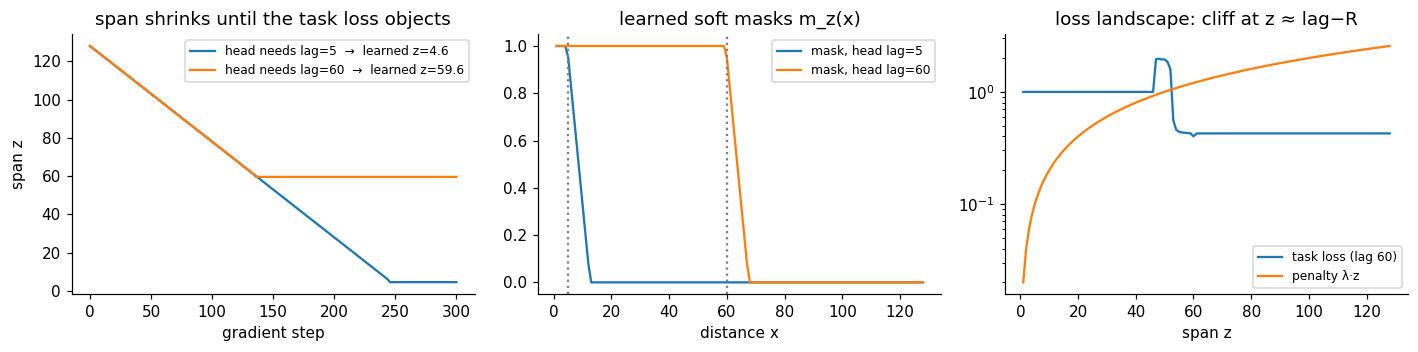

head lag  5: learned span    4.6 of 128  →  96% of the key positions skipped
head lag 60: learned span   59.6 of 128  →  53% of the key positions skipped


In [16]:
# =============================================================================
# Learned Soft Attention Spans
# =============================================================================
#
# Description:
# This experiment demonstrates how an attention head can learn a task-specific
# span that determines how far back in the sequence it is allowed to attend.
#
# Synthetic setup:
#   - A sequence of random value vectors is generated.
#   - Each attention head has a preferred lag, representing the position of
#     the token that is relevant to its task.
#   - The attention distribution is centered around this preferred lag.
#   - A learnable span z softly masks attention to distant tokens.
#
# Soft span mask:
#   The function span_mask(x, z) smoothly transitions from 1 for positions
#   inside the span to 0 for positions sufficiently outside it.
#   Increasing z therefore allows the head to access a larger context.
#
# Optimization objective:
#   The span is learned by minimizing:
#
#       task loss + lambda * span
#
#   The first term measures how accurately the attention output reconstructs
#   the target token value.
#   The second term penalizes unnecessarily large attention spans.
#
# Two heads are tested:
#   - lag = 5: the required information is close to the current position.
#   - lag = 60: the required information is much farther back.
#
# The experiment illustrates that different attention heads can learn different
# effective context lengths. A head that only needs nearby information can
# reduce its span, while a head requiring distant information must retain a
# larger span to avoid increasing the task loss.
#
# Visualizations:
#   1. Optimization trajectories showing how the learned span changes.
#   2. Learned soft attention masks for the two heads.
#   3. The task-loss and span-penalty landscape for the long-range head.
#
# =============================================================================

L, R, beta, dv, T = 128, 8, 0.6, 16, 400
Vseq = rng.normal(size=(T, dv))

def span_mask(x, z, R=R):
    return np.clip((R + z - x) / R, 0.0, 1.0)

def head_forward(z, lag, ts):
    x = np.arange(1, L + 1)                                   # distance to key
    logits = -beta * (x - lag) ** 2                           # content prior: "the relevant token is `lag` steps back"
    w = np.exp(logits) * span_mask(x, z)
    w = w / (w.sum() + 1e-12)                                 # renormalise after masking (as in the paper)
    out = np.stack([w @ Vseq[t - x] for t in ts])
    tgt = np.stack([Vseq[t - lag] for t in ts])
    return ((out - tgt) ** 2).mean(), w

ts = np.arange(L + 1, T)
def objective(z, lag, lam): return head_forward(z, lag, ts)[0] + lam * z

def train_span(lag, lam=0.02, z0=float(L), lr=25.0, steps=300):
    z, traj = z0, [z0]
    for _ in range(steps):
        eps = 0.5
        g = (objective(z + eps, lag, lam) - objective(z - eps, lag, lam)) / (2 * eps)
        z = float(np.clip(z - lr * g, 1.0, L)); traj.append(z)
    return z, traj

res = {lag: train_span(lag) for lag in (5, 60)}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
for lag, (zf, tr) in res.items():
    axes[0].plot(tr, label=f"head needs lag={lag}  →  learned z={zf:.1f}")
axes[0].set_xlabel("gradient step"); axes[0].set_ylabel("span z"); axes[0].legend(fontsize=8); axes[0].set_title("span shrinks until the task loss objects")
x = np.arange(1, L + 1)
for lag, (zf, _) in res.items():
    axes[1].plot(x, span_mask(x, zf), label=f"mask, head lag={lag}"); axes[1].axvline(lag, ls=":", color="gray")
axes[1].set_xlabel("distance x"); axes[1].set_title("learned soft masks m_z(x)"); axes[1].legend(fontsize=8)
zs = np.arange(1, L + 1, 1.0)
axes[2].plot(zs, [head_forward(z_, 60, ts)[0] for z_ in zs], label="task loss (lag 60)"); axes[2].plot(zs, 0.02 * zs, label="penalty λ·z")
axes[2].set_xlabel("span z"); axes[2].set_yscale("log"); axes[2].legend(fontsize=8); axes[2].set_title("loss landscape: cliff at z ≈ lag−R")
plt.tight_layout(); plt.show()
for lag, (zf, _) in res.items():
    print(f"head lag {lag:>2}: learned span {zf:6.1f} of {L}  →  {1 - zf/L:.0%} of the key positions skipped")

Different heads settle on **different spans** that match what they actually need (a local head ends up with a tiny window, a long-range head with a large one), instead of every head paying for the full context. (Each span lands right around the lag it needs; the soft ramp of width `R` explains the small offset.)

## 5 · Token-level dynamism: pruning, merging and KV eviction

### 5.1 Importance-based pruning (PoWER-BERT style)
Significance of token *j* = attention it receives from the `[CLS]` token, summed over heads. At every layer we keep only the top fraction, so the retained set adapts to the input. Here 12 of 96 tokens carry "signal" aligned with the classification query.

In [17]:
# =============================================================================
# Progressive Token Elimination for Efficient Attention
# =============================================================================
#
# Description:
# This experiment studies whether tokens can be progressively removed while
# preserving information that is important to a [CLS] query.
#
# Synthetic setup:
#   - 96 tokens with 32-dimensional representations are generated.
#   - Several tokens contain a strong signal aligned with a shared query
#     direction.
#   - Token 0 acts as the [CLS] token and is always preserved.
#   - Four attention heads are simulated using separate query and key
#     projections.
#
# Token significance:
#   For each attention head, the [CLS] attention distribution is computed.
#   The distributions are summed across heads to obtain a significance score
#   for every token.
#
# Progressive elimination:
#   At each stage, only a fraction of the currently retained tokens is kept.
#   Tokens with the highest [CLS] attention significance are retained, while
#   [CLS] itself is forced to remain in the sequence.
#
# Measurements:
#   - Number of tokens remaining after all elimination stages.
#   - Approximate attention FLOPs relative to processing the full sequence at
#     every stage.
#   - Recall of the artificially inserted signal tokens.
#   - Relative error of the final [CLS]-based attention output compared with
#     the full-token reference.
#
# The experiment illustrates the trade-off between reducing the attention
# computation and preserving information that contributes strongly to the
# [CLS] representation.
#
# =============================================================================

n_tok, d, heads = 96, 32, 4
q_dir = rng.normal(size=d); q_dir /= np.linalg.norm(q_dir)
X = rng.normal(size=(n_tok, d)) * 0.6
signal = rng.choice(np.arange(1, n_tok), 12, replace=False)
X[signal] += 6.0 * q_dir
X[0] = q_dir * 6.0                                            # [CLS] token
Wk = [np.eye(d) + 0.1 * rng.normal(size=(d, d)) for _ in range(heads)]
Wq = [np.eye(d) + 0.1 * rng.normal(size=(d, d)) for _ in range(heads)]

def cls_significance(Xc):
    sig = np.zeros(len(Xc))
    for hq, hk in zip(Wq, Wk):
        sig += softmax((Xc[0] @ hq) @ (Xc @ hk).T / np.sqrt(d))       # CLS row of the attention map
    return sig

def cls_output(Xc):
    W = np.mean([softmax((Xc[0] @ hq) @ (Xc @ hk).T / np.sqrt(d)) for hq, hk in zip(Wq, Wk)], 0)
    return W @ Xc

ref = cls_output(X)
print(f"{'kept tokens':>12} {'FLOPs vs full':>14} {'signal recall':>14} {'CLS-output err':>15}")
for schedule in [[1.0], [0.75, 0.75], [0.6, 0.6, 0.6], [0.5, 0.5, 0.5], [0.4, 0.4, 0.4], [0.3, 0.3, 0.3], [0.2, 0.2, 0.2]]:
    idx = np.arange(n_tok); flops = 0
    for keep in schedule:                                      # progressive elimination layer by layer
        flops += len(idx) ** 2
        sig = cls_significance(X[idx]); sig[0] = np.inf                # never drop CLS
        idx = idx[np.sort(np.argsort(-sig)[: max(2, int(round(len(idx) * keep)))])]
    kept_sig = np.isin(signal, idx).mean()
    print(f"{len(idx):>12} {flops/(len(schedule)*n_tok**2):>14.0%} {kept_sig:>14.0%} {rel_err(cls_output(X[idx]), ref):>15.3f}")

 kept tokens  FLOPs vs full  signal recall  CLS-output err
          96           100%           100%           0.000
          54            78%           100%           0.002
          21            50%           100%           0.005
          12            44%            92%           0.014
           6            39%            42%           0.095
           3            37%            17%           0.195
           2            35%             8%           0.382


### 5.2 Token merging (ToMe): bipartite soft matching + proportional attention
Instead of discarding tokens, merge the *r* most similar pairs (cosine similarity of keys) by **size-weighted averaging**. Attention over merged tokens adds `log(size)` to the logits so a merged token still counts as many tokens ("proportional attention"). Tokens here are redundant (64 tokens, 12 distinct clusters), like image patches of a uniform background.

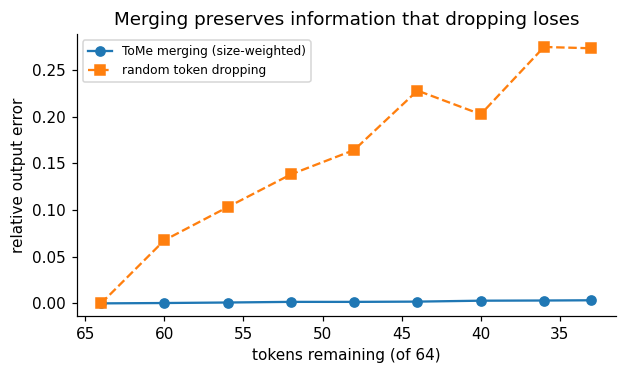

In [18]:
# =============================================================================
# Token Merging vs. Random Token Dropping
# =============================================================================
#
# Description:
# This experiment compares token merging with random token dropping as a way
# of reducing the number of tokens processed by an attention mechanism.
#
# Token Merging (ToMe-style):
#   - Tokens are split into two alternating groups.
#   - Cosine similarity is computed between tokens in the two groups.
#   - The most similar pairs are selected for merging.
#   - Their representations are combined using token-size weights.
#   - The resulting `size` values keep track of how many original tokens are
#     represented by each merged token.
#
# Size-weighted attention:
#   The attention logits include log(size), so a merged token receives weight
#   proportional to the number of original tokens represented by it.
#
# Baseline:
#   Randomly drops tokens until the same number of tokens remains as after
#   merging. Repeating the random selection 20 times gives an average error.
#
# Experiment:
#   A synthetic sequence is generated from several content clusters. A set of
#   probe queries is then used to compute a reference attention output over all
#   64 original tokens.
#
# For several reduction levels, the experiment compares:
#
#   - ToMe-style similarity-based merging.
#   - Random token dropping.
#
# The relative output error is measured against the full-token reference.
# The resulting plot shows how approximation error changes as the number of
# remaining tokens decreases.
#
# =============================================================================

def tome_merge(X, size, r):
    n = len(X); A, B = np.arange(0, n, 2), np.arange(1, n, 2)
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    sim = Xn[A] @ Xn[B].T
    best = sim.argmax(1); score = sim.max(1)
    pick = np.argsort(-score)[:r]
    Xs = X * size[:, None]; size = size.copy()
    for a_i, b_i in zip(A[pick], B[best[pick]]):
        Xs[b_i] += Xs[a_i]; size[b_i] += size[a_i]
    keep = np.setdiff1d(np.arange(n), A[pick])
    return Xs[keep] / size[keep][:, None], size[keep]

def attn_with_size(Q, Xm, size):
    S = Q @ Xm.T / np.sqrt(Q.shape[-1]) + np.log(size)[None, :]      # proportional attention
    return softmax(S) @ Xm

n_tok, d, C = 64, 32, 12
cent = rng.normal(size=(C, d)); lab = rng.integers(0, C, n_tok)
X = 1.5 * cent[lab] + 0.12 * rng.normal(size=(n_tok, d))
probe = rng.normal(size=(16, d))
ref = attn_with_size(probe, X, np.ones(n_tok))

rs = [0, 4, 8, 12, 16, 20, 24, 28, 31]
err_merge, err_drop, remain = [], [], []
for r in rs:
    Xm, sz = tome_merge(X, np.ones(n_tok), r)
    err_merge.append(rel_err(attn_with_size(probe, Xm, sz), ref)); remain.append(len(Xm))
    errs = []
    for _ in range(20):                                     # baseline: randomly drop the same number of tokens
        keep = np.sort(rng.choice(n_tok, len(Xm), replace=False))
        errs.append(rel_err(attn_with_size(probe, X[keep], np.ones(len(keep))), ref))
    err_drop.append(np.mean(errs))
plt.figure(figsize=(5.8, 3.5))
plt.plot(remain, err_merge, "o-", label="ToMe merging (size-weighted)"); plt.plot(remain, err_drop, "s--", label="random token dropping")
plt.gca().invert_xaxis(); plt.xlabel("tokens remaining (of 64)"); plt.ylabel("relative output error"); plt.legend(fontsize=8)
plt.title("Merging preserves information that dropping loses"); plt.tight_layout(); plt.show()

### 5.3 H2O: heavy-hitter KV-cache eviction during decoding
At each decoding step we keep a fixed **budget** of cached tokens. H2O tracks the *cumulative attention* each cached key has received and evicts the lowest-scoring one (protecting a recent window). We compare it with recency-only (sliding window) and random eviction on a stream where a handful of early "heavy-hitter" tokens keep attracting attention.

In [19]:
# =============================================================================
# Heavy-Hitter KV-Cache Eviction vs. Recency and Random Policies
# =============================================================================
#
# Description:
# This experiment simulates autoregressive decoding with a limited KV-cache
# budget and compares three cache eviction strategies:
#
#   - Recency:
#       Removes the oldest cached token when the cache is full.
#
#   - Random:
#       Removes a randomly selected cached token.
#
#   - H2O (Heavy-Hitter Oracle):
#       Tracks the cumulative attention received by cached tokens and preferentially
#       removes tokens with low accumulated attention, while preserving a recent
#       portion of the cache.
#
# Synthetic keys and values are generated for a sequence of T tokens. A small
# set of tokens is designated as "heavy hitters" by adding a shared key-space
# direction to their key vectors. The queries are biased toward the same
# direction, making these tokens disproportionately likely to receive
# attention.
#
# At every decoding step:
#
#   1. The current token is added to the cache.
#   2. Attention is computed over the retained cache.
#   3. The result is compared with attention over the complete history available
#      at that timestep.
#   4. The attention weight received by each cached token is accumulated.
#   5. If the cache exceeds the budget, the selected eviction policy removes
#      one token.
#
# The reported mean relative error measures how closely the limited-cache
# attention output approximates the full-history attention output.
#
# The final statistic counts how many of the synthetic heavy-hitter tokens
# remain in the cache after decoding.
#
# This is a synthetic demonstration rather than a benchmark of an actual
# language model or production KV-cache implementation.
#
# =============================================================================

T, d, budget = 400, 32, 48
u = rng.normal(size=d); u /= np.linalg.norm(u)
Kc = rng.normal(size=(T, d)) * 0.5; Vc = rng.normal(size=(T, d))
heavy = np.sort(rng.choice(np.arange(0, 250), 10, replace=False)); Kc[heavy] += 6.0 * u
Qs = 4.0 * u + rng.normal(size=(T, d)) * 0.5

def decode(policy, budget):
    cache, acc, errs = [], {}, []
    for t in range(T):
        cache.append(t); acc[t] = 0.0
        idx = np.array(cache)
        w = softmax(Qs[t] @ Kc[idx].T / np.sqrt(d)); out = w @ Vc[idx]
        wf = softmax(Qs[t] @ Kc[: t + 1].T / np.sqrt(d)); errs.append(rel_err(out, wf @ Vc[: t + 1]))
        for i, wi in zip(idx, w): acc[i] += wi
        if len(cache) > budget:
            recent = budget // 2
            if policy == "h2o":
                cand = cache[:-recent]; cache.remove(min(cand, key=lambda i: acc[i]))
            elif policy == "recency": cache.pop(0)
            elif policy == "random": cache.pop(rng.integers(0, len(cache) - 1))
    return np.mean(errs), cache

for pol in ["recency", "random", "h2o"]:
    e, final = decode(pol, budget)
    print(f"{pol:8} budget={budget}/{T}  mean rel. error {e:.3f}   heavy-hitters retained: {np.isin(heavy, final).sum()}/{len(heavy)}")

recency  budget=48/400  mean rel. error 1.221   heavy-hitters retained: 0/10
random   budget=48/400  mean rel. error 1.144   heavy-hitters retained: 0/10
h2o      budget=48/400  mean rel. error 0.207   heavy-hitters retained: 10/10


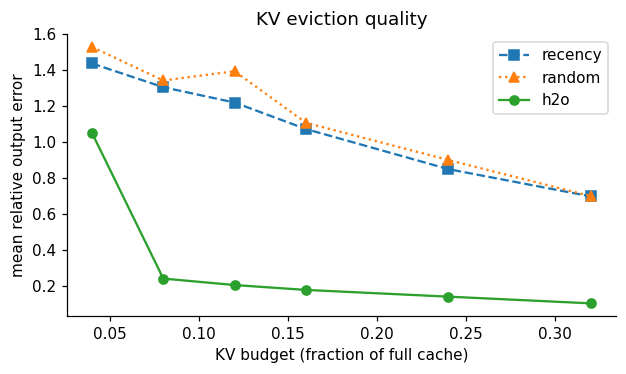

In [20]:
# Compare KV-cache eviction policies across several cache budgets.
# For each policy, measure mean relative output error against the full-cache reference.
# Plot error as a function of the fraction of the full KV cache that is retained.
# Lower error means the eviction policy better preserves the attention output.
budgets = [16, 32, 48, 64, 96, 128]
plt.figure(figsize=(5.8, 3.5))
for pol, st in [("recency", "s--"), ("random", "^:"), ("h2o", "o-")]:
    plt.plot([b / T for b in budgets], [decode(pol, b)[0] for b in budgets], st, label=pol)
plt.xlabel("KV budget (fraction of full cache)"); plt.ylabel("mean relative output error"); plt.legend(); plt.title("KV eviction quality"); plt.tight_layout(); plt.show()

## 6 · Interpretability: attention rollout vs. attention flow

The network is a DAG whose nodes are token positions per layer and whose edge weights are attention weights. We reproduce the worked example (tokens *keep / it / fun*, 3 layers of nodes):

* **Rollout** – multiply weights along a path, **sum over paths** → 0.5·0.1 + 0.1·0.4 + 0.4·0.5 = 0.29  
* **Flow** – capacity of each edge = its attention weight, compute the **maximum flow** (path weight = bottleneck) → 0.6

Rollout matrix (rows: bottom token, cols: top token)
 [[0.38 0.33 0.29]
 [0.22 0.37 0.41]
 [0.36 0.31 0.33]]

rollout(keep -> fun) = 0.29   (report/slide: 0.29)

Attention-flow matrix
 [[0.9 0.7 0.6]
 [0.5 0.8 0.9]
 [0.8 0.7 0.7]]

flow(keep -> fun) = 0.60   (report/slide: 0.6)


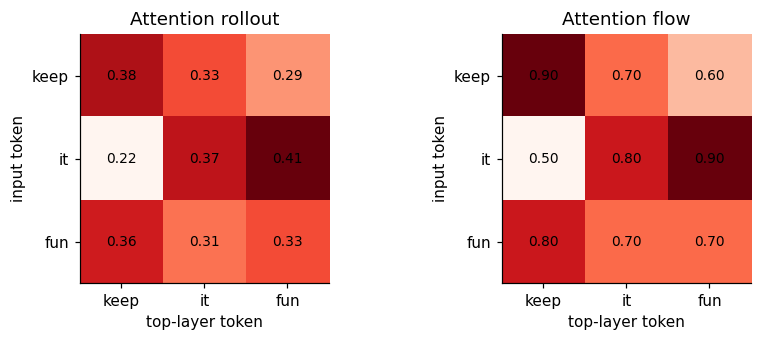

In [21]:
# =============================================================================
# Attention Rollout vs. Attention Flow on a Layered Attention Graph
# =============================================================================
#
# Description:
# This experiment compares two ways of measuring how attention information can
# propagate from an input token to a token in a later transformer layer:
#
#   1. Attention rollout:
#      Multiplies the attention matrices from consecutive layers. Each entry
#      represents the sum of products of attention weights over all possible
#      paths between the corresponding bottom and top tokens.
#
#   2. Attention flow:
#      Treats the attention matrices as capacities on a layered directed graph
#      and computes the maximum flow between each input/output token pair using
#      the Edmonds-Karp algorithm.
#
# The example uses three tokens:
#
#     "keep" -> "it" -> "fun"
#
# with two layers of attention edges. The resulting rollout and maximum-flow
# matrices are visualized side by side.
#
# The `max_flow()` implementation performs breadth-first searches to find
# augmenting paths and updates the residual graph until no additional flow can
# reach the target node.
#
# The `flow_matrix()` helper converts the sequence of attention matrices into
# one layered capacity graph so that maximum-flow computation can be performed
# between arbitrary input and output tokens.
#
# Note:
# Rollout and flow answer different mathematical questions. Rollout aggregates
# contributions across paths according to products of edge weights, whereas
# maximum flow measures the largest amount of capacity that can be routed
# through the layered graph. Therefore, their attribution values need not agree.
#
# =============================================================================

names = ["keep", "it", "fun"]
# E1[i, j]: weight from bottom node i to middle node j ; E2[j, k]: middle node j to top node k
# (the 'keep' row and the last column of E2 match the figure; other entries are illustrative)
E1 = np.array([[0.5, 0.1, 0.4],
               [0.1, 0.5, 0.4],
               [0.4, 0.1, 0.5]])
E2 = np.array([[0.5, 0.4, 0.1],
               [0.1, 0.5, 0.4],
               [0.3, 0.2, 0.5]])

rollout = E1 @ E2                                    # sum over all 2-edge paths of the product of weights
print("Rollout matrix (rows: bottom token, cols: top token)\n", np.round(rollout, 3))
print(f"\nrollout(keep -> fun) = {rollout[0, 2]:.2f}   (report/slide: 0.29)")

# ---- maximum flow (Edmonds-Karp) on the layered graph
def max_flow(cap, s, t):
    cap = cap.copy(); N = len(cap); flow = 0.0
    while True:
        parent = -np.ones(N, int); parent[s] = s; queue = [s]
        while queue and parent[t] < 0:
            u_ = queue.pop(0)
            for v_ in range(N):
                if parent[v_] < 0 and cap[u_, v_] > 1e-12: parent[v_] = u_; queue.append(v_)
        if parent[t] < 0: return flow
        b, v_ = np.inf, t
        while v_ != s: b = min(b, cap[parent[v_], v_]); v_ = parent[v_]
        v_ = t
        while v_ != s: cap[parent[v_], v_] -= b; cap[v_, parent[v_]] += b; v_ = parent[v_]
        flow += b

def flow_matrix(edge_mats):
    sizes = [edge_mats[0].shape[0]] + [m.shape[1] for m in edge_mats]; off = np.cumsum([0] + sizes)
    cap = np.zeros((off[-1], off[-1]))
    for L_, m in enumerate(edge_mats): cap[off[L_]:off[L_+1], off[L_+1]:off[L_+2]] = m
    return cap, off

cap, off = flow_matrix([E1, E2])
F = np.array([[max_flow(cap, off[0] + i, off[2] + k) for k in range(3)] for i in range(3)])
print("\nAttention-flow matrix\n", np.round(F, 3))
print(f"\nflow(keep -> fun) = {F[0, 2]:.2f}   (report/slide: 0.6)")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
for ax, M, t in zip(axes, [rollout, F], ["Attention rollout", "Attention flow"]):
    im = ax.imshow(M, cmap="Reds"); ax.set_xticks(range(3)); ax.set_xticklabels(names); ax.set_yticks(range(3)); ax.set_yticklabels(names)
    ax.set_title(t); ax.set_xlabel("top-layer token"); ax.set_ylabel("input token")
    for i in range(3):
        for j in range(3): ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=9)
plt.tight_layout(); plt.show()

### 6.1 Why raw last-layer attention can mislead
Information is mixed across layers. On a random 6-layer stack (attention plus a residual connection, as in the original rollout formulation, `Â = 0.5·A + 0.5·I`), compare the last layer's raw attention to the rolled-out map for a token at one end of the sequence.

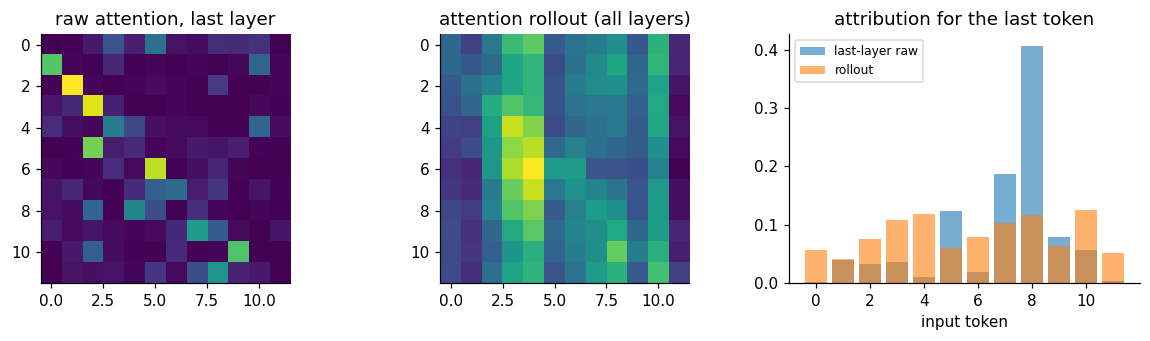

rank correlation (Spearman) raw-vs-rollout for last token: 0.287


In [22]:
# =============================================================================
# Attention Rollout Across Transformer Layers
# =============================================================================
#
# Description:
# This experiment demonstrates attention rollout, which combines attention
# information across multiple transformer layers instead of examining only the
# final layer.
#
# The experiment creates a synthetic stack of attention matrices with a small
# amount of local structure. Residual connections are incorporated by mixing
# each attention matrix with the identity matrix:
#
#     Â = 0.5 A + 0.5 I
#
# The rollout matrix is then computed recursively across all layers:
#
#     R_l = Â_l · R_{l-1}
#
# This produces an estimate of how information can propagate from input tokens
# through the sequence of transformer layers.
#
# The experiment compares:
#
#   - Raw attention from the final layer.
#   - Attention rollout accumulated across all layers.
#   - Token-level attribution to the final output token using both methods.
#
# The final Spearman-style rank correlation compares whether the tokens that
# receive high attribution in the last layer are also highly ranked by the
# accumulated rollout attribution.
#
# Note:
# Attention rollout is an attribution/interpretability construction. It should
# not automatically be interpreted as a causal explanation of model behavior.
#
# =============================================================================

n, layers = 12, 6
A_layers = []
for _ in range(layers):
    S = rng.normal(size=(n, n)) * 1.5 + 2.5 * np.eye(n, k=-1) + 1.0 * np.eye(n, k=-3)      # weak local-ish structure
    A_layers.append(softmax(S))
A_hat = [0.5 * A + 0.5 * np.eye(n) for A in A_layers]

R_ = np.eye(n)
for Ah in A_hat: R_ = Ah @ R_                               # recursive rollout: R_l = Â_l · R_{l-1}
last = A_layers[-1]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
axes[0].imshow(last, cmap="viridis"); axes[0].set_title("raw attention, last layer")
axes[1].imshow(R_, cmap="viridis"); axes[1].set_title("attention rollout (all layers)")
axes[2].bar(range(n), last[-1], alpha=0.6, label="last-layer raw"); axes[2].bar(range(n), R_[-1], alpha=0.6, label="rollout")
axes[2].set_title("attribution for the last token"); axes[2].set_xlabel("input token"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("rank correlation (Spearman) raw-vs-rollout for last token:",
      np.round(np.corrcoef(np.argsort(np.argsort(last[-1])), np.argsort(np.argsort(R_[-1])))[0, 1], 3))

## 7 · Take-aways

| Mechanism | What is made adaptive? | Exact? | What the experiment showed |
|---|---|---|---|
| Standard attention | weights (per query) | – | same keys, different queries → different distributions |
| GQA / MQA | # of distinct K/V heads | approx. | KV-cache ∝ #groups; error grows as heads share more |
| PagedAttention / Quantization | memory layout / precision | layout exact, quantization approx. | 70B model 280 → 35 GB from FP32 → INT4 |
| FlashAttention | data movement | **exact** | identical output, largest intermediate is `Br×Bc` not `n×n` |
| Longformer / BigBird | which pairs (fixed) | approx. | local misses far partners; global + random recover some |
| entmax / top-k / LSH / routing | which pairs (input-dependent) | approx. | far more mass kept than fixed masks at equal density when relevance is content-based |
| Adaptive span | how far each head looks | approx. | heads learn different spans matching their needs |
| PoWER-BERT / ToMe / H2O | which tokens exist / stay cached | approx. | merging beats dropping; heavy-hitter eviction beats recency |
| Rollout / flow | – (analysis tool) | – | attributions differ from raw attention; 0.29 vs 0.6 in the toy DAG |

**Overall message:** attention has evolved from a fixed all-to-all operation into a framework where computation is *allocated*: per pair, per head, per token, per cache slot, according to the input and the available resources.